## Análise de habitos e notas de estudantes
Notebook criado para realiar análises e previsões de notas e exames escolares com base em **hábitos** e **características** de estudantes.
- *Bibliotecas utilizadas*: Pandas🐼 e Seaborn📊.

Realizando as importações das bibliotecas necessárias e, logo em seguida, defini um nome para cada uma delas

In [ ]:
import pandas as pd
import seaborn as sns

Coloquei a base de dados dentro do codigo para trabalharmos com ela

In [176]:
df = pd.read_csv(r".\data\dataset_aula03_student_habits_performance.csv")

## Visualização inicial dos dados

Para conhecer a estrutura da base de dados, exibimos as cinco primeiras linhas utilizando o método `head()`.    

In [177]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## Visualização das últimas linhas

Em seguida, exibimos as cinco últimas linhas da base utilizando o método `tail()`. Isso ajuda a verificar se os dados estão consistentes do início ao fim.

In [178]:
df.tail()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7
999,S1999,19,Female,4.3,2.9,1.9,No,89.4,7.1,Good,2,Bachelor,Average,8,No,74.9


## Informações gerais da base

Utilizamos o método `info()` para visualizar a estrutura do conjunto de dados, incluindo o número de registros, os tipos das colunas e a quantidade de valores preenchidos.

In [179]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

## Verificação de valores nulos

Percebemos que a coluna `parental_education_level` possui alguns valores ausentes. Por isso, realizamos uma contagem para identificar quantos registros estavam vazios.

In [180]:
df["parental_education_level"].isna().sum()

np.int64(91)

## Contagem dos valores preenchidos

Também verificamos quantos registros da coluna `parental_education_level` já possuíam um valor preenchido.

In [181]:
df["parental_education_level"].notnull().sum()

np.int64(909)

## Tratamento dos valores ausentes

Como não era possível identificar qual seria o valor correto para os registros vazios, substituímos todos eles por `"Desconhecido"` utilizando o método `fillna()`.

In [182]:
df["parental_education_level"] = df["parental_education_level"].fillna("Desconhecido")

## Verificação do tratamento

Após a substituição, realizamos uma nova contagem dos valores nulos para confirmar que todos os registros foram preenchidos corretamente.

In [183]:
df["parental_education_level"].isna().sum()

np.int64(0)

## Verificação do tratamento

Após a substituição, realizamos uma nova contagem dos valores nulos para confirmar que todos os registros foram preenchidos corretamente.

In [184]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       1000 non-null   str    
 12  internet_quality               1000 non-null   str    
 13  

## Valores únicos da coluna

Para conhecer todas as categorias presentes na coluna `parental_education_level`, utilizamos o método `unique()`.

In [185]:
df["parental_education_level"].unique()

<ArrowStringArray>
['Master', 'High School', 'Bachelor', 'Desconhecido']
Length: 4, dtype: str

## Seleção das variáveis

Criamos uma lista contendo apenas as colunas numéricas que seriam utilizadas para calcular a matriz de correlação.

In [186]:
colunas = [
    "age",
    "study_hours_per_day",
    "social_media_hours",
    "netflix_hours",
    "attendance_percentage",
    "sleep_hours",
    "exercise_frequency",
    "mental_health_rating",
    "exam_score",
    ]

## Matriz de correlação

Geramos um mapa de calor (Heatmap) para visualizar a correlação entre as variáveis numéricas. Esse gráfico facilita a identificação de relações positivas, negativas ou fracas entre os dados.

<Axes: >

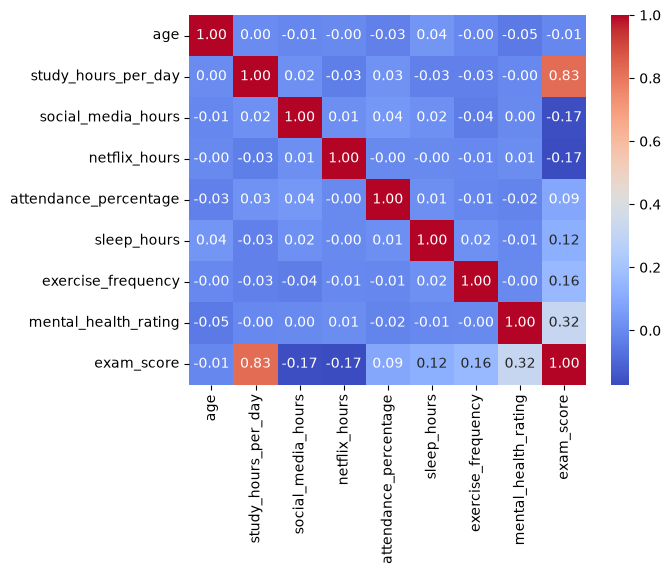

In [197]:
sns.heatmap(data=df[colunas].corr(), annot=True, cmap="coolwarm", fmt= ".2f")

## Relação entre horas de estudo e nota

Criamos um gráfico de dispersão entre as variáveis `study_hours_per_day` e `exam_score` para verificar a relação entre as horas de estudo e o desempenho no exame.

Observa-se uma tendência positiva, indicando que, em geral, quanto maior o tempo de estudo, maior tende a ser a nota obtida.

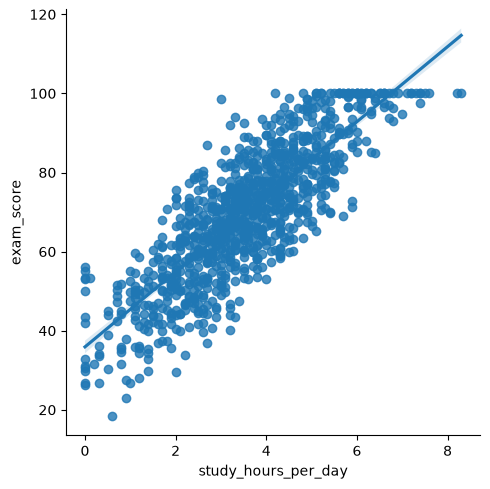

In [188]:
sns.lmplot(data=df,x="study_hours_per_day",y="exam_score");

## Relação entre horas de Netflix e saúde mental

Neste gráfico analisamos a relação entre as horas assistindo Netflix e a avaliação da saúde mental.

Os pontos estão bastante dispersos, indicando uma correlação fraca entre essas duas variáveis.

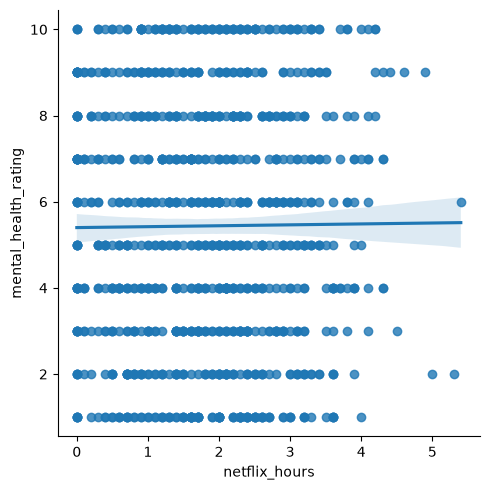

In [189]:
sns.lmplot(data=df,x="netflix_hours",y="mental_health_rating");

## Relação entre horas de Netflix e nota

Por fim, analisamos a relação entre o tempo gasto assistindo Netflix e a nota do exame.

O gráfico apresenta uma leve tendência negativa, sugerindo que um maior tempo dedicado à plataforma pode estar associado a notas um pouco menores.

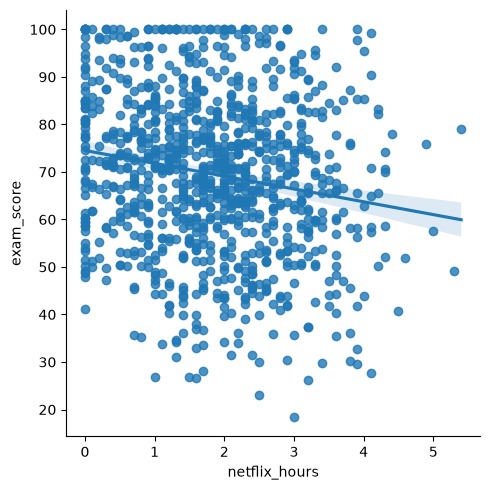

In [190]:
sns.lmplot(data=df,x="netflix_hours",y="exam_score");

## Comparação das médias

Dividimos os estudantes em dois grupos:

- Pessoas que estudam **5 horas ou mais por dia**;
- Pessoas que estudam **menos de 2 horas por dia**.

Em seguida, calculamos a média das notas de cada grupo para comparar o desempenho entre eles.

In [3]:
filtro_horas_altas = df["study_hours_per_day"] >= 5
filtro_horas_baixas = df["study_hours_per_day"] < 2

media_alta = df[filtro_horas_altas]["exam_score"].mean()
media_baixa = df[filtro_horas_baixas]["exam_score"].mean()

print(f"A média das pessoas que estudaram 5 ou mais horas foi {media_alta:.2f}.Já a média, das pessoas que estudaram menos que duas horas foi {media_baixa:.2f}")

NameError: name 'df' is not defined

In [ ]:
df.to_csv("base_estudantes_tratado.csv")

### Relatório de Análise — Hábitos e Desempenho dos Alunos

- ## 1. Engenharia de Prompt
- # A ultima resposta foi a melhor, pois ele entregou de uma forma mais detalhada, e com mais informações, e sendo bem assertiva na resposta


-  Pergunta 3 :  Você é um analista de dados educacionais experiente. Esta base tem 1000 alunos, com hábitos e a nota final (exam_score). Identifique os 3 hábitos que mais impactam a nota, apresente cada um com o número que comprova e escreva em linguagem clara para a direção de uma escola.

-  Resposta 3 : Analisando os 1.000 alunos da base, os três hábitos com maior impacto na nota final (exam_score) são:

Posição	Hábito	Evidência (correlação com a nota)	Interpretação
- 1º	Horas de estudo por dia (study_hours_per_day)	r = 0,825	É o fator que mais influencia o desempenho. Quanto mais horas de estudo diário, maior tende a ser a nota. A relação é muito forte.
- 2º	Saúde mental (mental_health_rating)	r = 0,322	Alunos com melhor avaliação da saúde mental apresentam, em média, notas mais altas. A relação é moderada.
- 3º	Tempo assistindo Netflix (netflix_hours)	r = -0,172	Quanto maior o tempo gasto assistindo Netflix, menor tende a ser a nota. A relação é fraca, mas é a terceira mais influente entre os hábitos analisados.

-  Resumo para a direção da escola

A análise da base de 1.000 estudantes mostra que o fator mais importante para o desempenho acadêmico é o tempo dedicado aos estudos, apresentando uma correlação de 0,825, considerada muito forte. Em seguida, destaca-se a saúde mental dos alunos, com correlação de 0,322, indicando que estudantes com melhor bem-estar emocional tendem a obter melhores resultados. O terceiro hábito com maior impacto é o tempo gasto assistindo Netflix, que apresenta correlação negativa de -0,172, sugerindo que o excesso desse tipo de entretenimento está associado a uma pequena redução no desempenho escolar.

Conclusão

Os resultados indicam que a escola pode obter melhores resultados ao:

Incentivar uma rotina consistente de estudos;
Desenvolver ações de apoio à saúde mental dos estudantes;
Orientar os alunos sobre o equilíbrio entre lazer digital e tempo de estudo.

Esses três fatores foram os que apresentaram a maior associação estatística com a nota final entre todos os hábitos disponíveis na base de dados.



- ## 2. Novas análises

- **A qualidade da dieta do aluno (diet_quality) faz diferença na nota? Mostre a média por grupo.**

Sim. A qualidade da dieta apresenta uma diferença nas notas médias dos alunos, embora o efeito seja relativamente pequeno.

Qualidade da dieta (diet_quality)	Média da nota (exam_score)
- Fair (Regular)	70,43
- Good (Boa)	69,37
- Poor (Ruim)	68,13
-Interpretação:

Os dados mostram que:

- Alunos com dieta Regular (Fair) obtiveram a maior média de nota (70,43).
- Alunos com dieta Boa (Good) tiveram média de 69,37.
- Alunos com dieta Ruim (Poor) apresentaram a menor média (68,13).

A diferença entre a maior e a menor média é de aproximadamente 2,30 pontos.

Conclusão para a direção da escola

A qualidade da alimentação parece estar associada ao desempenho escolar, mas a diferença observada é pequena quando comparada a fatores como horas de estudo ou saúde mental. Assim, embora hábitos alimentares saudáveis sejam importantes para o bem-estar dos estudantes, nesta base de dados eles não aparecem entre os fatores que mais influenciam a nota final.

- **Alunos com trabalho de meio período (part_time_job) vão pior nas notas?**

Sim, mas a diferença é pequena.

Trabalho de meio período (part_time_job)	Média da nota (exam_score)
- Não	69,84
- Sim	68,74
- Interpretação :

- Alunos sem trabalho de meio período tiveram média de 69,84 pontos.
- Alunos com trabalho de meio período tiveram média de 68,74 pontos.
- A diferença entre os grupos é de aproximadamente 1,09 ponto.

Conclusão para a direção da escola

Os estudantes que possuem um trabalho de meio período apresentam, em média, notas ligeiramente menores do que aqueles que não trabalham. No entanto, a diferença observada é de apenas 1,09 ponto, indicando que, nesta base de dados, ter um emprego de meio período não parece ser um dos fatores mais determinantes para o desempenho acadêmico quando comparado a hábitos como horas de estudo ou saúde mental.



- ## 3. Cuidados e Ética no uso da IA
Quando perguntei se a idade tinha relação com a nota, percebi que a IA deu uma resposta que parecia certa, mas era preciso conferir os dados para ter certeza. Isso mostrou que nem tudo o que a IA responde está correto.

Por isso, é perigoso confiar totalmente na IA. Ela pode interpretar os dados de forma errada ou tirar conclusões que não são verdadeiras. Se ninguém verificar as informações, isso pode causar erros no trabalho ou em um relatório.

A IA é uma ferramenta que ajuda bastante, mas sempre é importante conferir os dados e ver se a resposta faz sentido antes de usá-la.